# Email Spam Detection with Machine Learning

## Oasis Infobyte Data Science Internship

### Task 4

### Objective

Build a Natural Language Processing (NLP) model that classifies messages as Spam or Ham using machine learning.

### Technologies Used

- Python
- Pandas
- NLTK
- Scikit-Learn
- Matplotlib
- Seaborn
- WordCloud

## Import Libraries

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from wordcloud import WordCloud

## Download Stopwords

In [6]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rahul\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

## Load Dataset

In [7]:
df = pd.read_csv("spam.csv", encoding="latin1")

In [8]:
#if dataset have extra column
df = df.iloc[:, :2]
df.columns = ["Label", "Message"]

In [9]:
#Display dataset:
df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Explore Dataset

In [10]:
df.shape

(5572, 2)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Label    5572 non-null   object
 1   Message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [12]:
df.describe()

,Label,Message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [13]:
df.isnull().sum()

Label      0
Message    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(403)

In [15]:
#Remove duplicates:
df = df.drop_duplicates()

## Class Distribution

In [16]:
# Count spam and ham:
df["Label"].value_counts()

Label
ham     4516
spam     653
Name: count, dtype: int64

In [17]:
# Percentage:
(df["Label"].value_counts(normalize=True))*100

Label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

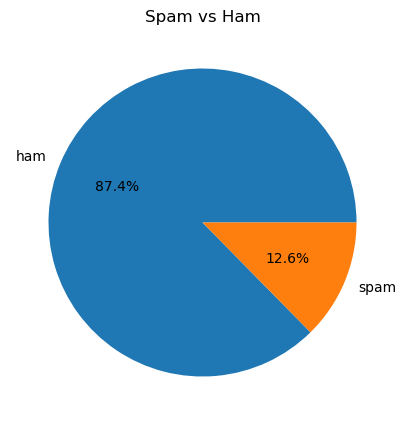

In [18]:
# Visualization:
plt.figure(figsize=(5,5))

df["Label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Spam vs Ham")

plt.ylabel("")

plt.show()

## Text Preprocessing

In [20]:
stop_words = set(stopwords.words("english"))

In [21]:
# Cleaning function:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]','',text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [22]:
# Apply:
df["Clean_Message"] = df["Message"].apply(clean_text)

## What is TF-IDF?

TF-IDF (Term Frequency–Inverse Document Frequency) is a technique used to convert text into numerical features. It assigns higher importance to words that appear frequently in a document but rarely across all documents, making them more useful for classification.

## TF-IDF

In [23]:
tfidf = TfidfVectorizer()

In [24]:
X = tfidf.fit_transform(df["Clean_Message"])

In [25]:
# Encode labels:
y = df["Label"].map({"ham":0,"spam":1})

## Train-Test Split

In [26]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model 1

## Multinomial Naive Bayes

In [27]:
nb = MultinomialNB()

nb.fit(X_train,y_train)

pred_nb = nb.predict(X_test)

## Model 2

## Logistic Regression

In [28]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

## Evaluation

In [29]:
# Function:
def evaluate(actual,pred):

    print("Accuracy :",accuracy_score(actual,pred))

    print("Precision :",precision_score(actual,pred))

    print("Recall :",recall_score(actual,pred))

    print("F1 Score :",f1_score(actual,pred))

    print()

    print(classification_report(actual,pred))

## Evaluate:

In [30]:
print("Naive Bayes")

evaluate(y_test,pred_nb)

Naive Bayes
Accuracy : 0.960348162475822
Precision : 1.0
Recall : 0.7172413793103448
F1 Score : 0.8353413654618473

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       1.00      0.72      0.84       145

    accuracy                           0.96      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.96      0.96      0.96      1034



In [31]:
print("Logistic Regression")

evaluate(y_test,pred_lr)

Logistic Regression
Accuracy : 0.9439071566731141
Precision : 0.9306930693069307
Recall : 0.6482758620689655
F1 Score : 0.7642276422764228

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       889
           1       0.93      0.65      0.76       145

    accuracy                           0.94      1034
   macro avg       0.94      0.82      0.87      1034
weighted avg       0.94      0.94      0.94      1034



In [32]:
print("Logistic Regression")

evaluate(y_test,pred_lr)

Logistic Regression
Accuracy : 0.9439071566731141
Precision : 0.9306930693069307
Recall : 0.6482758620689655
F1 Score : 0.7642276422764228

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       889
           1       0.93      0.65      0.76       145

    accuracy                           0.94      1034
   macro avg       0.94      0.82      0.87      1034
weighted avg       0.94      0.94      0.94      1034



## Confusion Matrix

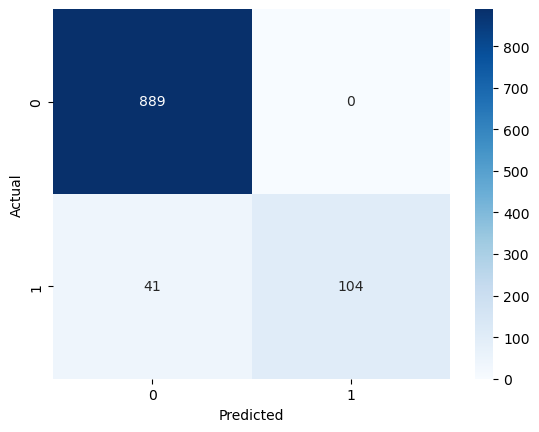

In [33]:
cm = confusion_matrix(y_test,pred_nb)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Why is Recall Important in Spam Detection?

Recall is important because it measures how many actual spam messages are correctly identified. A high recall minimizes the number of spam messages that reach a user's inbox, helping protect users from phishing, scams, and malicious content.

## Spam WordCloud

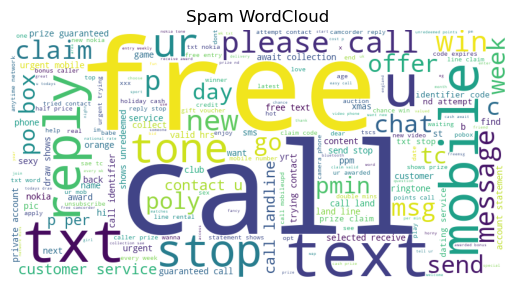

In [34]:
spam_words = " ".join(df[df["Label"]=="spam"]["Clean_Message"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_words)

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Spam WordCloud")

plt.show()

## Ham WordCloud

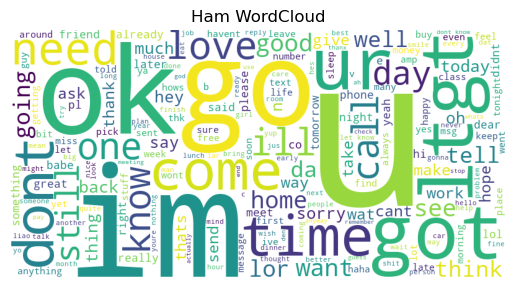

In [35]:
ham_words = " ".join(df[df["Label"]=="ham"]["Clean_Message"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_words)

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Ham WordCloud")

plt.show()

## Conclusion

- Loaded and explored the SMS Spam Collection dataset.
- Performed text preprocessing including lowercase conversion, punctuation removal, and stopword removal.
- Converted text into numerical features using TF-IDF Vectorizer.
- Trained two classification models:
  - Multinomial Naive Bayes
  - Logistic Regression
- Evaluated both models using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.
- Generated WordCloud visualizations for Spam and Ham messages.
- Selected the better-performing model based on evaluation metrics.